# Prototype #1

In [1]:
import pandas as pd
import kagglehub
from autogluon.timeseries import TimeSeriesDataFrame, TimeSeriesPredictor

c:\workspace\StockPredictor\StockPredictor_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#Download latest version
path = kagglehub.dataset_download("nelgiriyewithana/world-stock-prices-daily-updating")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\s3phi\.cache\kagglehub\datasets\nelgiriyewithana\world-stock-prices-daily-updating\versions\399


In [3]:
#Load Data in pandas
data_path = path+"\World-Stock-Prices-Dataset.csv"
stockdata = pd.read_csv(data_path)
#Create DataFrame
df = pd.DataFrame(stockdata)

<>:2: SyntaxWarning: invalid escape sequence '\W'
<>:2: SyntaxWarning: invalid escape sequence '\W'
C:\Users\s3phi\AppData\Local\Temp\ipykernel_14600\4072858615.py:2: SyntaxWarning: invalid escape sequence '\W'
  data_path = path+"\World-Stock-Prices-Dataset.csv"


In [4]:
df

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Brand_Name,Ticker,Industry_Tag,Country,Capital Gains
0,2025-07-03 00:00:00-04:00,6.630000,6.740000,6.615000,6.640000,4209664.0,0.0,0.0,peloton,PTON,fitness,usa,NaN
1,2025-07-03 00:00:00-04:00,560.780029,569.659973,560.739990,569.239990,1528700.0,0.0,0.0,mastercard,MA,finance,usa,NaN
2,2025-07-03 00:00:00-04:00,2.130000,2.130000,2.090000,2.090000,40800.0,0.0,0.0,ubisoft,UBSFY,gaming,france,NaN
3,2025-07-03 00:00:00-04:00,139.110001,139.500000,137.320007,137.910004,28646000.0,0.0,0.0,amd,AMD,technology,usa,NaN
4,2025-07-03 00:00:00-04:00,1292.000000,1302.260010,1279.760010,1297.180054,2006200.0,0.0,0.0,netflix,NFLX,entertainment,usa,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
310117,2000-01-03 00:00:00-05:00,14.968750,15.593750,14.687500,15.500000,7843200.0,0.0,0.0,amd,AMD,technology,usa,NaN
310118,2000-01-03 00:00:00-05:00,4.785835,4.810098,4.634192,4.670587,8014400.0,0.0,0.0,nike,NKE,apparel,usa,NaN
310119,2000-01-03 00:00:00-05:00,13.765435,13.911876,13.490859,13.582384,906400.0,0.0,0.0,hershey company,HSY,food & beverage,usa,NaN
310120,2000-01-03 00:00:00-05:00,0.903091,0.910259,0.843363,0.894729,30091200.0,0.0,0.0,nvidia,NVDA,technology,usa,NaN


In [5]:
df["Date"].iloc[-1]

'2000-01-03 00:00:00-05:00'

In [6]:
brands = df["Brand_Name"].unique().tolist() #create a list of all brands in the df

In [7]:
len(brands)

62

In [8]:
brands

['peloton',
 'mastercard',
 'ubisoft',
 'amd',
 'netflix',
 'foot locker',
 'philips',
 '3m',
 'fedex',
 'coinbase',
 'procter & gamble',
 'uber',
 'johnson & johnson',
 'the home depot',
 'southwest airlines',
 "mcdonald's",
 'hilton',
 'toyota',
 'zoominfo',
 'marriott',
 'airbnb',
 'lvmh',
 'jpmorgan chase & co',
 'cisco',
 'unilever',
 'adobe',
 'shopify',
 'logitech',
 'puma',
 'american eagle outfitters',
 'tesla',
 'starbucks',
 'nvidia',
 'salesforce / slack',
 'honda',
 'porsche',
 'hershey company',
 'chipotle',
 'bmw group',
 'pinterest',
 'costco',
 'amazon',
 'microsoft',
 'delta air lines',
 'nintendo',
 'roblox',
 'the walt disney company',
 'zoom video communications',
 'spotify',
 'google',
 'target',
 'nike',
 'apple',
 'visa',
 'colgate palmolive',
 'american express',
 'crocs',
 'adidas',
 'the coca-cola company',
 'twitter',
 'nordstrom',
 'block']

In [9]:
brand_AUSWAHL = brands[57] #Platzhalter für eine spätere Auswahl vom User
brand_AUSWAHL

'adidas'

In [10]:

#Filter Brand_Name by apple and filter columns by Date, Close, Brand_Name
df_apple = df.loc[df["Brand_Name"] == brand_AUSWAHL, ["Date", "Close", "Brand_Name"]]
display(df_apple)

,Date,Close,Brand_Name
81,2025-07-03 00:00:00-04:00,121.930000,adidas
118,2025-07-02 00:00:00-04:00,122.860001,adidas
214,2025-07-01 00:00:00-04:00,121.449997,adidas
231,2025-06-30 00:00:00-04:00,117.019997,adidas
298,2025-06-27 00:00:00-04:00,116.830002,adidas
...,...,...,...
252987,2006-06-06 00:00:00-04:00,19.594389,adidas
253024,2006-06-05 00:00:00-04:00,20.245869,adidas
253080,2006-06-02 00:00:00-04:00,20.275932,adidas
253127,2006-06-01 00:00:00-04:00,19.895071,adidas


In [11]:
len(df_apple)

4854

In [12]:
df_apple["Close"].iloc[-1]

np.float64(20.015344619750977)

In [13]:
df_apple_preproc = df_apple.rename(columns={"Date": "timestamp", "Close": "target", "Brand_Name": "item_id"})
df_apple_preproc.head(5)

,timestamp,target,item_id
81,2025-07-03 00:00:00-04:00,121.930000,adidas
118,2025-07-02 00:00:00-04:00,122.860001,adidas
214,2025-07-01 00:00:00-04:00,121.449997,adidas
231,2025-06-30 00:00:00-04:00,117.019997,adidas
298,2025-06-27 00:00:00-04:00,116.830002,adidas


In [14]:
df_apple_preproc["item_id"] = df_apple_preproc['item_id'].astype("string")
df_apple_preproc["timestamp"] = df_apple_preproc['timestamp'].astype("string")
df_apple_preproc.dtypes

timestamp    string[python]
target              float64
item_id      string[python]
dtype: object

In [15]:
timecut = df_apple_preproc["timestamp"].str.slice(stop=10) #Cut hh:mm:ss and timezone
timecut

81        2025-07-03
118       2025-07-02
214       2025-07-01
231       2025-06-30
298       2025-06-27
             ...    
252987    2006-06-06
253024    2006-06-05
253080    2006-06-02
253127    2006-06-01
253179    2006-05-31
Name: timestamp, Length: 4854, dtype: string

In [16]:
df_apple_preproc["timestamp"] = timecut
df_apple_preproc

,timestamp,target,item_id
81,2025-07-03,121.930000,adidas
118,2025-07-02,122.860001,adidas
214,2025-07-01,121.449997,adidas
231,2025-06-30,117.019997,adidas
298,2025-06-27,116.830002,adidas
...,...,...,...
252987,2006-06-06,19.594389,adidas
253024,2006-06-05,20.245869,adidas
253080,2006-06-02,20.275932,adidas
253127,2006-06-01,19.895071,adidas


In [17]:
df_apple_preproc["timestamp"] = pd.to_datetime(timecut) #convert string into datetime64
df_apple_preproc.dtypes

timestamp    datetime64[ns]
target              float64
item_id      string[python]
dtype: object

In [18]:
df_apple_reordered =  df_apple_preproc[['item_id', 'timestamp', 'target']] #Reordering columns

df_apple_reordered

,item_id,timestamp,target
81,adidas,2025-07-03,121.930000
118,adidas,2025-07-02,122.860001
214,adidas,2025-07-01,121.449997
231,adidas,2025-06-30,117.019997
298,adidas,2025-06-27,116.830002
...,...,...,...
252987,adidas,2006-06-06,19.594389
253024,adidas,2006-06-05,20.245869
253080,adidas,2006-06-02,20.275932
253127,adidas,2006-06-01,19.895071


# Preproccessing in AutoGluon

In [19]:
df_irregular = TimeSeriesDataFrame(
    pd.DataFrame(df_apple_reordered)
)
df_irregular.head(10)

target
item_id timestamp             
adidas  2025-07-03  121.930000
        2025-07-02  122.860001
        2025-07-01  121.449997
        2025-06-30  117.019997
        2025-06-27  116.830002
        2025-06-27  116.930000
        2025-06-26  112.849998
        2025-06-25  114.739998
        2025-06-24  115.809998
        2025-06-23  114.559998

In [20]:
df_regular = df_irregular.convert_frequency(freq="D")
df_filled = df_regular.fill_missing_values()
df_filled.head(10)

target
item_id timestamp            
adidas  2006-05-31  20.015345
        2006-06-01  19.895071
        2006-06-02  20.275932
        2006-06-03  20.275932
        2006-06-04  20.275932
        2006-06-05  20.245869
        2006-06-06  19.594389
        2006-06-07  19.323776
        2006-06-08  18.672302
        2006-06-09  18.993025

# Equip Model

In [21]:
data = TimeSeriesDataFrame.from_data_frame(
    df = df_filled,
    id_column="item_id",
    timestamp_column="timestamp"
)
data

target
item_id timestamp             
adidas  2006-05-31   20.015345
        2006-06-01   19.895071
        2006-06-02   20.275932
        2006-06-03   20.275932
        2006-06-04   20.275932
...                        ...
        2025-06-29  116.880001
        2025-06-30  117.019997
        2025-07-01  121.449997
        2025-07-02  122.860001
        2025-07-03  121.930000

[6974 rows x 1 columns]

In [22]:
prediction_length = 30
train_data, test_data = data.train_test_split(prediction_length)

predictor = TimeSeriesPredictor(prediction_length=prediction_length).fit(
    train_data, presets="bolt_base",
)

Beginning AutoGluon training...
AutoGluon will save models to 'c:\workspace\CrimeMap\AutogluonModels\ag-20250706_062815'
=================== System Info ===================
AutoGluon Version:  1.3.0
Python Version:     3.12.1
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.19045
CPU Count:          8
GPU Count:          0
Memory Avail:       3.45 GB / 15.70 GB (22.0%)
Disk Space Avail:   32.65 GB / 475.50 GB (6.9%)
Setting presets to: bolt_base

Fitting with arguments:
{'enable_ensemble': True,
 'eval_metric': WQL,
 'hyperparameters': {'Chronos': {'model_path': 'bolt_base'}},
 'known_covariates_names': [],
 'num_val_windows': 1,
 'prediction_length': 30,
 'quantile_levels': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
 'random_seed': 123,
 'refit_every_n_windows': 1,
 'refit_full': False,
 'skip_model_selection': True,
 'target': 'target',
 'verbosity': 2}

Inferred time series frequency: 'D'
Provided train_data has 6944 rows, 1 time series. Median time

Model not specified in predict, will default to the model with the best validation score: Chronos[bolt_base]


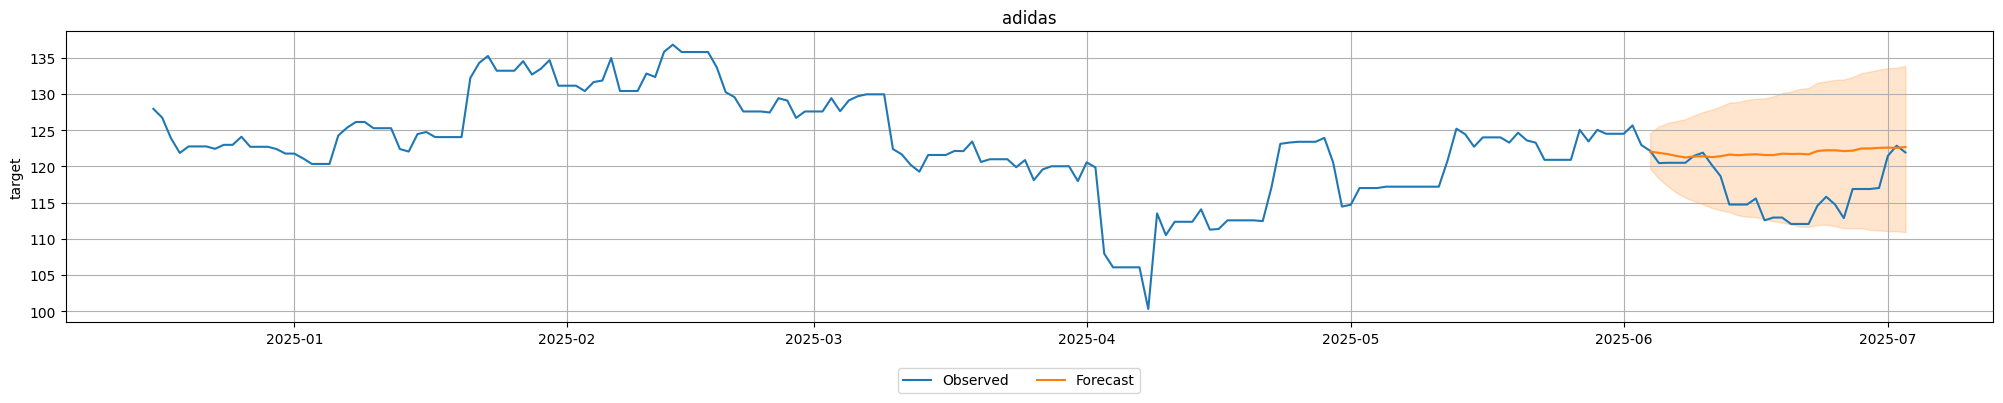

In [23]:
predictions = predictor.predict(train_data)
predictor.plot(
    data=data,
    predictions=predictions,
    item_ids=data.item_ids[:2],
    max_history_length=200,
);

In [24]:
prediction_length = 30
train_data, test_data = data.train_test_split(prediction_length)

predictor = TimeSeriesPredictor(prediction_length=prediction_length).fit(
    train_data, presets="bolt_base", hyperparameters={"Chronos": {"fine_tune": True, "fine_tune_lr": 1e-4, "fine_tune_steps": 4000}},
    time_limit=60,
)

Beginning AutoGluon training... Time limit = 60s
AutoGluon will save models to 'c:\workspace\CrimeMap\AutogluonModels\ag-20250706_062826'
=================== System Info ===================
AutoGluon Version:  1.3.0
Python Version:     3.12.1
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.19045
CPU Count:          8
GPU Count:          0
Memory Avail:       3.19 GB / 15.70 GB (20.3%)
Disk Space Avail:   32.65 GB / 475.50 GB (6.9%)
Setting presets to: bolt_base

Fitting with arguments:
{'enable_ensemble': True,
 'eval_metric': WQL,
 'hyperparameters': {'Chronos': {'fine_tune': True,
                                 'fine_tune_lr': 0.0001,
                                 'fine_tune_steps': 4000}},
 'known_covariates_names': [],
 'num_val_windows': 1,
 'prediction_length': 30,
 'quantile_levels': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
 'random_seed': 123,
 'refit_every_n_windows': 1,
 'refit_full': False,
 'skip_model_selection': True,
 'target': '

In [25]:
predictions = predictor.predict(train_data)
predictor.plot(
    data=data,
    predictions=predictions,
    item_ids=data.item_ids[:2],
    max_history_length=200,
);

Model not specified in predict, will default to the model with the best validation score: Chronos[autogluon__chronos-bolt-small]


In [26]:
predictor = TimeSeriesPredictor.load("C:\workspace\CrimeMap\AutogluonModels\\ag-20250523_070003")

<>:1: SyntaxWarning: invalid escape sequence '\w'
<>:1: SyntaxWarning: invalid escape sequence '\w'
C:\Users\s3phi\AppData\Local\Temp\ipykernel_14600\1413103349.py:1: SyntaxWarning: invalid escape sequence '\w'
  predictor = TimeSeriesPredictor.load("C:\workspace\CrimeMap\AutogluonModels\\ag-20250523_070003")
C:\Users\s3phi\AppData\Local\Temp\ipykernel_14600\1413103349.py:1: SyntaxWarning: invalid escape sequence '\w'
  predictor = TimeSeriesPredictor.load("C:\workspace\CrimeMap\AutogluonModels\\ag-20250523_070003")


FileNotFoundError: No such file 'C:\workspace\CrimeMap\AutogluonModels\ag-20250523_070003\predictor.pkl'

Model not specified in predict, will default to the model with the best validation score: Chronos[autogluon__chronos-bolt-small]


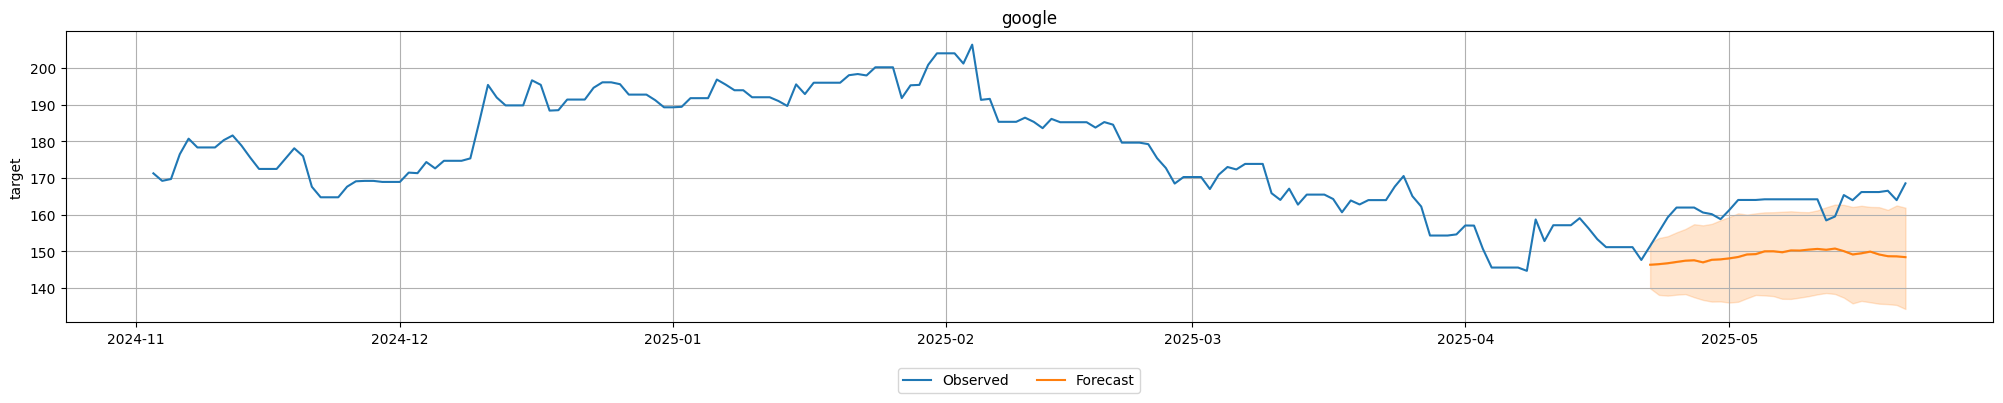

In [ ]:
predictions = predictor.predict(train_data)
predictor.plot(
    data=data,
    predictions=predictions,
    item_ids=data.item_ids[:2],
    max_history_length=200,
);